# Сессионное задание

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import kurtosis
from scipy.optimize import linear_sum_assignment
from scipy.signal import find_peaks
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler, StandardScaler
import umap.umap_ as umap

warnings.filterwarnings('ignore')

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
signal_df = pd.read_csv('Run200_Wave_0_1.txt', header=None)
print("Формат данных через Pandas:", signal_df.shape)

Формат данных через Pandas: (23479, 1)


Полный размер загруженной матрицы: (23479, 504)
Размерность матрицы сигналов для анализа: (23479, 500)


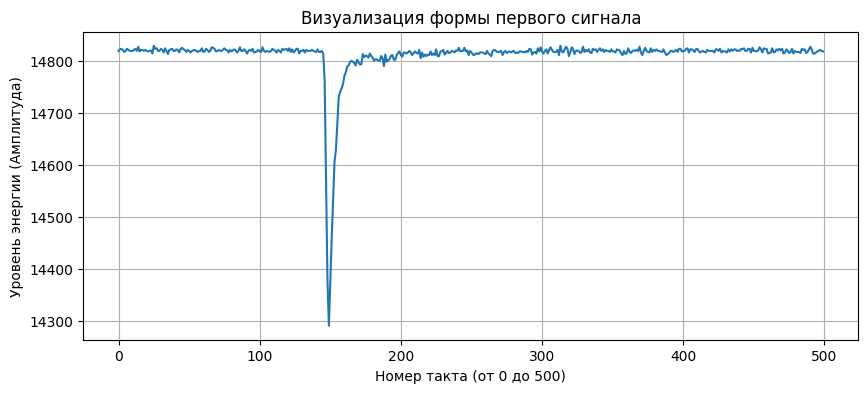

In [ ]:
raw_data = np.loadtxt('Run200_Wave_0_1.txt')
print(f"Полный размер загруженной матрицы: {raw_data.shape}")

# отделяем первые 4 колонки метаданных
metadata = raw_data[:, :4]

# отделяем 500 колонок, описывающих форму сигналов
signals = raw_data[:, 4:]
print(f"Размерность матрицы сигналов для анализа: {signals.shape}")

# визуализация одного любого сигнала (например, первого в списке), чтобы проверить его форму
plt.figure(figsize=(10, 4))
plt.plot(signals[0])
plt.title("Визуализация формы первого сигнала")
plt.xlabel("Номер такта (от 0 до 500)")
plt.ylabel("Уровень энергии (Амплитуда)")
plt.grid(True)
plt.show()

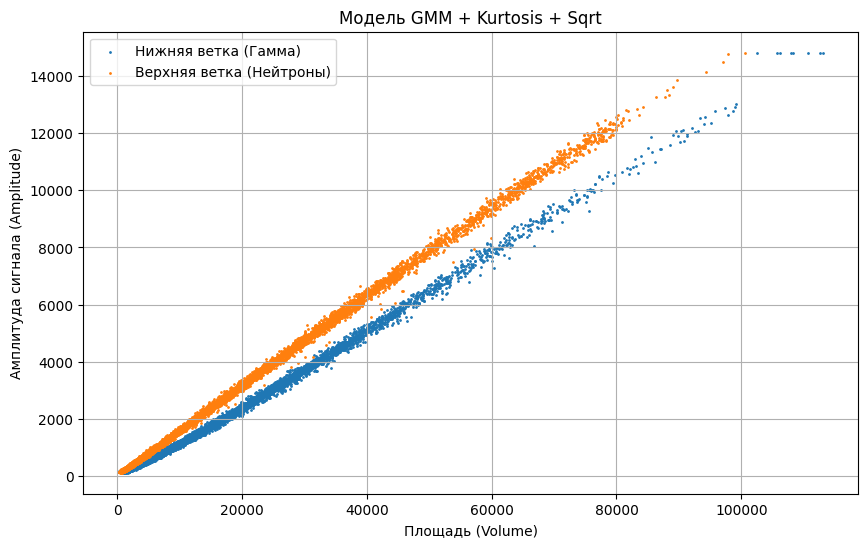

Класс 0 (Синие): 12198 шт.
Класс 1 (Оранжевые): 11281 шт.


In [ ]:
# 1. Базовая предобработка
baselines = np.mean(signals[:, :50], axis=1, keepdims=True)
signals_inverted = baselines - signals
amplitudes = np.max(signals_inverted, axis=1)
volumes = np.sum(signals_inverted, axis=1)
safe_volumes = np.where(volumes <= 0, 1e-5, volumes)

# 2. Набор признаков: Геометрия + Kurtosis + Корень
ratio = amplitudes / safe_volumes
angles = np.arctan2(amplitudes, safe_volumes)
kurt_values = kurtosis(signals_inverted, axis=1)
root_volumes = np.sqrt(np.abs(volumes))  # Извлечение корня сглаживает левый край графика

# Собираем матрицу признаков
features_ultra = np.column_stack((root_volumes, angles, ratio, kurt_values))

# Используем RobustScaler (защита от выбросов и насыщения ФЭУ)
scaler = RobustScaler()
features_scaled = scaler.fit_transform(features_ultra)

# 3. Обучаем модель GMM с ковариацией 'tied'
gmm = GaussianMixture(n_components=2, covariance_type='tied', random_state=42, max_iter=500)
final_labels = gmm.fit_predict(features_scaled)

# 4. Автоматическое выравнивание классов
cluster_centers = gmm.means_
if cluster_centers[0, 1] > cluster_centers[1, 1]:
    final_labels = 1 - final_labels

# 5. Визуализация результатов
plt.figure(figsize=(10, 6))
plt.scatter(volumes[final_labels == 0], amplitudes[final_labels == 0], s=1, c='tab:blue', label='Нижняя ветка (Гамма)')
plt.scatter(volumes[final_labels == 1], amplitudes[final_labels == 1], s=1, c='tab:orange', label='Верхняя ветка (Нейтроны)')
plt.title("Модель GMM + Kurtosis + Sqrt")
plt.xlabel("Площадь (Volume)")
plt.ylabel("Амплитуда сигнала (Amplitude)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Класс 0 (Синие): {np.sum(final_labels == 0)} шт.")
print(f"Класс 1 (Оранжевые): {np.sum(final_labels == 1)} шт.")


In [ ]:
file_name = 'submission_v015.csv'

submission_df = pd.DataFrame({
    'index': range(len(final_labels)),
    'cluster': final_labels
})

submission_df.to_csv(file_name, index=False)
print(f"Файл '{file_name}' успешно создан.")


Файл 'submission_v015.csv' успешно создан.
